In [1]:
DIR_INPUT = './output_fig'
DIR_OUTPUT = './output_fig/supp'

## Model performance

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
df_metric_makrov_censor_large = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric_ipcw_correct.csv'), 
    index_col=0
)
df_metric_makrov_censor_large['model_type'] = df_metric_makrov_censor_large['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_makrov_censor_large = df_metric_makrov_censor_large.loc[
    ~(
        df_metric_makrov_censor_large['model_type'].str.contains('Coxnet')|
        (
            df_metric_makrov_censor_large['model_type'].str.contains('xgboost_mono') & 
            df_metric_makrov_censor_large['descriptor'].str.contains('more g')
        )
    ),:
]
df_metric_makrov_censor_large['model_type'] = df_metric_makrov_censor_large['model_type'].replace('xgboost_mono', 'XGBMono')

df_metric_makrov_censor_large['ds_name'] = 'Sim-Main'
df_metric_makrov_censor_large['ds_name_code'] = ds_name



ds_name = 'markov_32feat_11t5g_less_balanced'
df_metric_makrov_censor_imbalance = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric_ipcw_correct.csv'), 
    index_col=0
)
df_metric_makrov_censor_imbalance['model_type'] = df_metric_makrov_censor_imbalance['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_makrov_censor_imbalance = df_metric_makrov_censor_imbalance.loc[
    ~(
        df_metric_makrov_censor_imbalance['model_type'].str.contains('Coxnet')|
        (
            df_metric_makrov_censor_imbalance['model_type'].str.contains('xgboost_mono') & 
            df_metric_makrov_censor_imbalance['descriptor'].str.contains('more g')
        )
    ),:
]
df_metric_makrov_censor_imbalance['model_type'] = df_metric_makrov_censor_imbalance['model_type'].replace('xgboost_mono', 'XGBMono')
df_metric_makrov_censor_imbalance['descriptor'] = df_metric_makrov_censor_imbalance['descriptor'].replace('SurvSurfTaddTG_dydg','LossDyDg')
df_metric_makrov_censor_imbalance['ds_name'] = 'Sim-LackProg'
df_metric_makrov_censor_imbalance['ds_name_code'] = ds_name


ds_name = 'house_price_traj'
df_metric_house_price = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric_ipcw_correct.csv'), 
    index_col=0
)
df_metric_house_price['model_type'] = df_metric_house_price['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_house_price = df_metric_house_price.loc[
    ~(
        df_metric_house_price['model_type'].str.contains('Coxnet')|
        (
            df_metric_house_price['model_type'].str.contains('xgboost_mono') & 
            df_metric_house_price['descriptor'].str.contains('more g')
        )
    ),:
]
df_metric_house_price['model_type'] = df_metric_house_price['model_type'].replace('xgboost_mono', 'XGBMono')
df_metric_house_price['ds_name'] = 'RW-Property'
df_metric_house_price['ds_name_code'] = ds_name


ds_name = 'real_NCT00981058_inject'
df_metric_trial = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric_ipcw_correct.csv'), 
    index_col=0
)
df_metric_trial['model_type'] = df_metric_trial['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_trial = df_metric_trial.loc[
    ~(
        df_metric_trial['model_type'].str.contains('Coxnet')|
        (
            df_metric_trial['model_type'].str.contains('xgboost_mono') & 
            df_metric_trial['descriptor'].str.contains('more g')
        )
    ),:
]
df_metric_trial['model_type'] = df_metric_trial['model_type'].replace('xgboost_mono', 'XGBMono')
df_metric_trial['ds_name'] = 'RW-TRAE'
df_metric_trial['ds_name_code'] = ds_name


In [3]:
df_metric_makrov_censor_large['descriptor'].unique()

array(['LossDyDg', 'LossSumo', 'LossSumo(more g)', 'standard',
       'standard(more g)'], dtype=object)

In [4]:
df_metric_makrov_censor_large['model_type'].value_counts()

model_type
DeepHit                             15
CoxTime                             10
RandomSurvivalForest                10
SurvSurf2DTaddTGNormTG               5
GradientBoostingSurvivalAnalysis     2
CoxPHSurvivalAnalysis                1
XGBMono                              1
Name: count, dtype: int64

In [5]:
df_metric_makrov_censor_imbalance['model_type'].value_counts()

model_type
DeepHit                             15
RandomSurvivalForest                10
SurvSurf2DTaddTGNormTG               5
CoxTime                              5
GradientBoostingSurvivalAnalysis     2
CoxPHSurvivalAnalysis                1
XGBMono                              1
Name: count, dtype: int64

In [6]:
set(df_metric_makrov_censor_large.columns) == set(df_metric_makrov_censor_imbalance.columns)

True

In [7]:
df_metric_makrov_censor_large.columns

Index(['run_id', 'model_type', 'intrg_brier_ipcw_by_subj',
       'mean_auc_ipcw_by_subj', 'intrg_brier_ipcw_by_g', 'mean_auc_ipcw_by_g',
       'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'intrg_brier_intrvl_imputed',
       'intrg_mse_certain_obs_ipcw_by_sbj', 'intrg_mse_certain_obs', 'mse',
       'mae', 'descriptor', 'median_prop_t_violated', 'median_max_violation',
       'max_prop_t_violated', 'max_max_violation', 'ds_name', 'ds_name_code'],
      dtype='object')

/tmp/ipykernel_333314/945190349.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/945190349.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


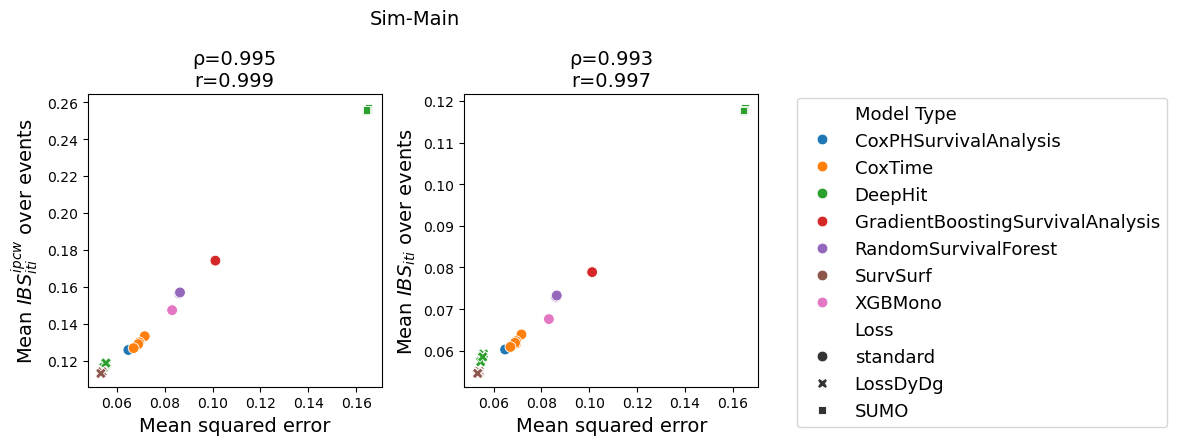

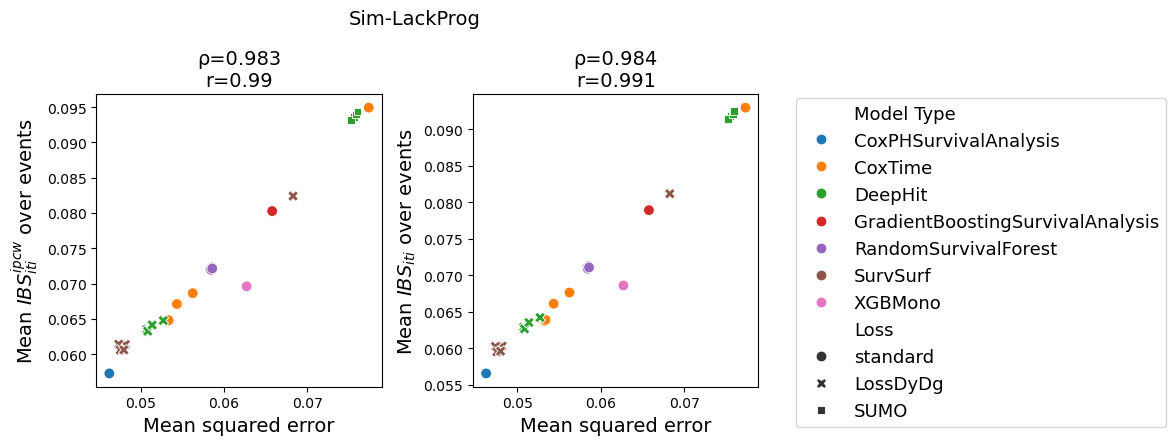

In [8]:
from scipy.stats import spearmanr, pearsonr
xy_fontsize = 14
for df, title in [
    (df_metric_makrov_censor_large, 'Sim-Main'),
    (df_metric_makrov_censor_imbalance, 'Sim-LackProg'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
    axes = axes.flatten()
    counter = 0
    for col_y, col_y_pretty, ax in [
        ('intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events', axes[0]),
        ('intrg_brier_intrvl_imputed', 'Mean $IBS_{iti}$ over events', axes[1]),
    ]:
        counter += 1
        col_hue = 'Model Type'
        col_style = 'Loss'
        col_x = 'mse'

        df_plot = df.copy()
        df_plot = df_plot.loc[
            df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
            (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
        ]
        df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
        df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo(more g)','SUMO(more g)')
        df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

        df_plot.loc[
            df_plot['max_prop_t_violated'] == 0,
            ['median_max_violation', 'max_max_violation']
        ] = 0
        df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
        df_plot = df_plot.sort_values([col_hue, col_style])

        sns.scatterplot(
            data=df_plot,
            x=col_x,
            y=col_y,
            hue=col_hue,
            style=col_style,
            ax=ax,
            s=60
        )

        if counter < 2:
            plt.legend().remove()
            ax.legend().remove()
        else:
            plt.legend(bbox_to_anchor = [1.1, 1.02], fontsize=xy_fontsize-1)
        
        corr_s = spearmanr(df_plot[col_x], df_plot[col_y])[0]
        corr_p = pearsonr(df_plot[col_x], df_plot[col_y])[0]
        
        ax.set_xlabel('Mean squared error', fontsize=xy_fontsize)
        ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
        ax.set_title(f'ρ={corr_s:.3g}\nr={corr_p:.3g}', fontsize=xy_fontsize)
    ds_name = df['ds_name_code'].iloc[0]
    fig.suptitle(title, x=0.35, fontsize=xy_fontsize)
    fig.tight_layout()
    fig.savefig(os.path.join(DIR_OUTPUT, f'MSE_vs_IBS_all_{ds_name}_ipcwless_ipcw_correct.pdf'), bbox_inches="tight")

In [9]:
df.columns

Index(['run_id', 'model_type', 'intrg_brier_ipcw_by_subj',
       'mean_auc_ipcw_by_subj', 'intrg_brier_ipcw_by_g', 'mean_auc_ipcw_by_g',
       'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'intrg_brier_intrvl_imputed',
       'intrg_mse_certain_obs_ipcw_by_sbj', 'intrg_mse_certain_obs', 'mse',
       'mae', 'descriptor', 'median_prop_t_violated', 'median_max_violation',
       'max_prop_t_violated', 'max_max_violation', 'ds_name', 'ds_name_code'],
      dtype='object')

/tmp/ipykernel_333314/3735421164.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/3735421164.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/3735421164.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/3735421164.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


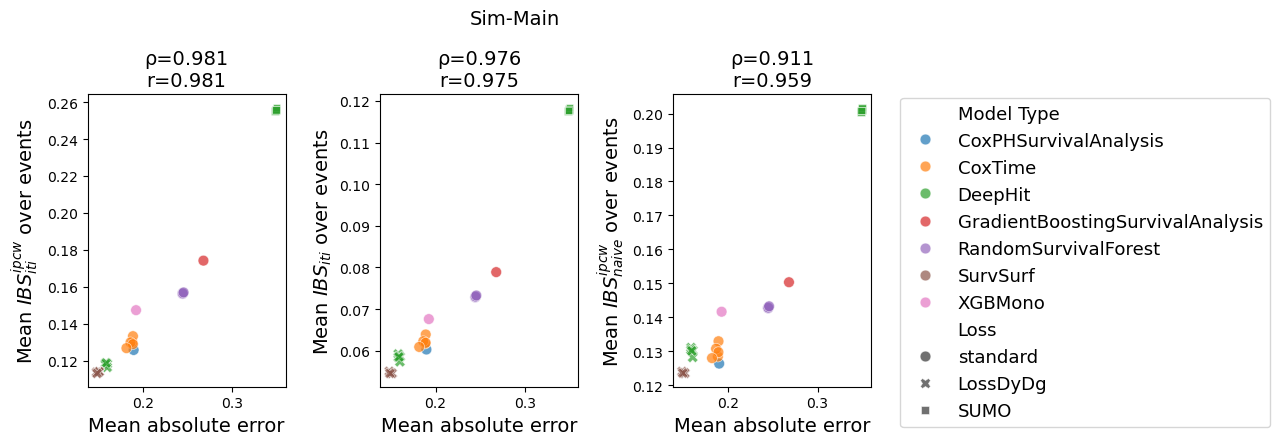

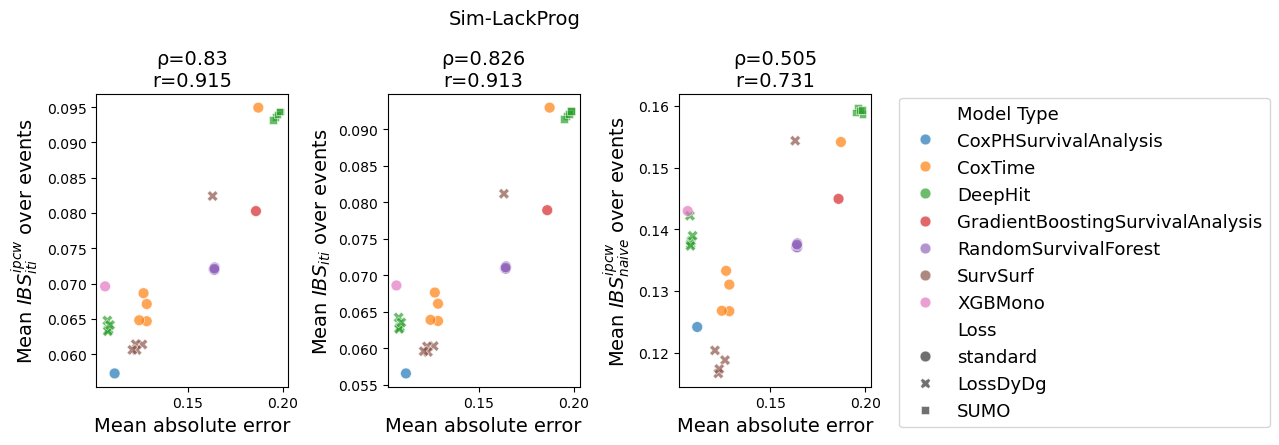

In [10]:
from scipy.stats import spearmanr, pearsonr
xy_fontsize = 14
for df, title in [
    (df_metric_makrov_censor_large, 'Sim-Main'),
    (df_metric_makrov_censor_imbalance, 'Sim-LackProg'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True)
    axes = axes.flatten()
    counter = 0
    for col_y, col_y_pretty, ax in [
        ('intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events', axes[0]),
        ('intrg_brier_intrvl_imputed', 'Mean $IBS_{iti}$ over events', axes[1]),
        ('intrg_brier_ipcw_by_subj', 'Mean $IBS^{ipcw}_{naive}$ over events', axes[2]),
    ]:
        counter += 1
        col_hue = 'Model Type'
        col_style = 'Loss'
        col_x = 'mae'

        df_plot = df.copy()
        df_plot = df_plot.loc[
            df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
            (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
        ]
        df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
        df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo(more g)','SUMO(more g)')
        df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

        df_plot.loc[
            df_plot['max_prop_t_violated'] == 0,
            ['median_max_violation', 'max_max_violation']
        ] = 0
        df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
        df_plot = df_plot.sort_values([col_hue, col_style])

        sns.scatterplot(
            data=df_plot,
            x=col_x,
            y=col_y,
            hue=col_hue,
            style=col_style,
            ax=ax,
            s=60,
            lw=0.5,
            alpha=0.7
        )

        if counter < 3:
            plt.legend().remove()
            ax.legend().remove()
        else:
            plt.legend(bbox_to_anchor = [1.1, 1.02], fontsize=xy_fontsize-1)
        
        corr_s = spearmanr(df_plot[col_x], df_plot[col_y])[0]
        corr_p = pearsonr(df_plot[col_x], df_plot[col_y])[0]
        
        ax.set_xlabel('Mean absolute error', fontsize=xy_fontsize)
        ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
        ax.set_title(f'ρ={corr_s:.3g}\nr={corr_p:.3g}', fontsize=xy_fontsize)
    ds_name = df['ds_name_code'].iloc[0]
    fig.suptitle(title, x=0.4, fontsize=xy_fontsize)
    fig.tight_layout()
    fig.savefig(os.path.join(DIR_OUTPUT, f'MAE_vs_IBS_all_{ds_name}_ipcwless_ipcw_correct.pdf'), bbox_inches="tight")

/tmp/ipykernel_333314/2553480917.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/2553480917.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


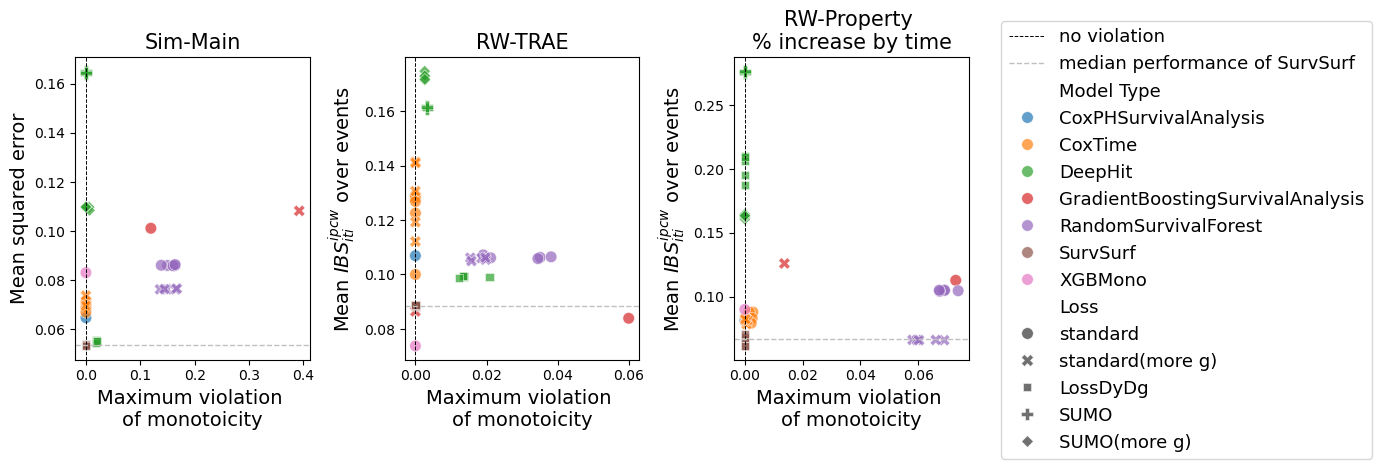

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes = axes.flatten()
xy_fontsize = 14
counter = 0
for df, col_y, col_y_pretty, title, ax in [
    (df_metric_makrov_censor_large, 'mse', 'Mean squared error','Sim-Main', axes[0]),
    (df_metric_trial,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','RW-TRAE', axes[1]),
    (df_metric_house_price,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','RW-Property \n% increase by time', axes[2]),
]:
    counter += 1
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'max_max_violation'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'standard(more g)','LossDyDg', 'LossSumo', 'LossSumo(more g)']) &
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo(more g)','SUMO(more g)')
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    med_survsurf = df_plot.loc[df_plot['model_type'] == 'SurvSurf',col_y].median()
    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
    df_plot = df_plot.sort_values([col_hue, col_style])

    ax.axvline(x=0, ls='--', color='black', lw=0.7, label='no violation')
    ax.axhline(y=med_survsurf, ls='--', color='silver', lw=1, label='median performance of SurvSurf')
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax,
        s=70,
        lw=0.5,
        alpha=0.7
    )

    if counter < 3:
        plt.legend().remove()
        ax.legend().remove()
    else:
        plt.legend(bbox_to_anchor = [1.1, 1.15], fontsize=xy_fontsize-1)
    
    ax.set_title(title, fontsize=xy_fontsize+1)
    ax.set_xlabel('Maximum violation \nof monotoicity', fontsize=xy_fontsize)
    ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
fig.tight_layout()
fig.savefig(os.path.join(DIR_OUTPUT, f'performance_violation_scatter__all_main_ds_more_g_ipcw_correct.pdf'), bbox_inches="tight")

/tmp/ipykernel_333314/2603187959.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_333314/2603187959.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


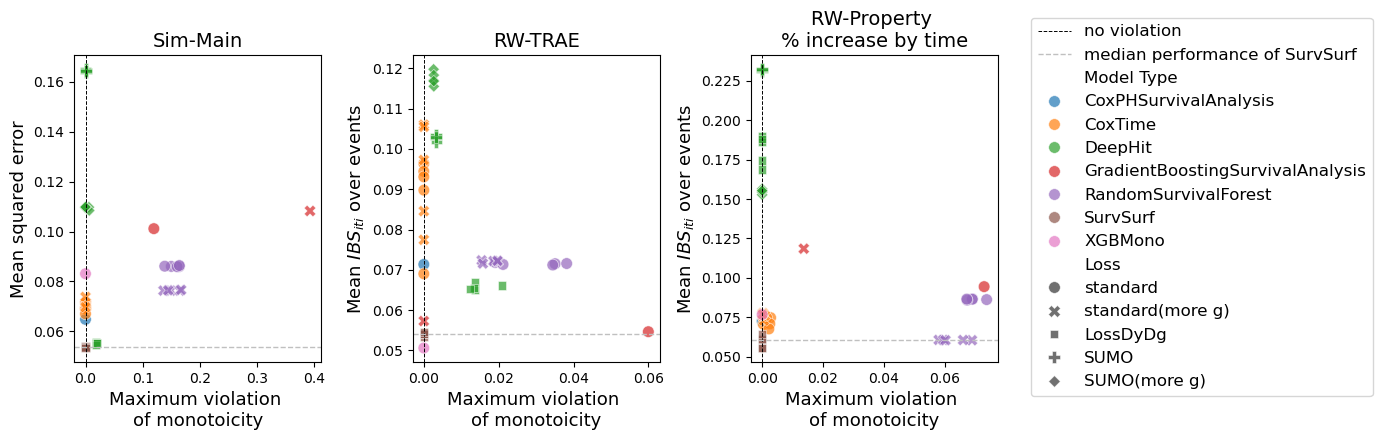

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes = axes.flatten()
xy_fontsize = 13
counter = 0
for df, col_y, col_y_pretty, title, ax in [
    (df_metric_makrov_censor_large, 'mse', 'Mean squared error','Sim-Main', axes[0]),
    (df_metric_trial,'intrg_brier_intrvl_imputed', 'Mean $IBS_{iti}$ over events','RW-TRAE', axes[1]),
    (df_metric_house_price,'intrg_brier_intrvl_imputed', 'Mean $IBS_{iti}$ over events','RW-Property \n% increase by time', axes[2]),
]:
    counter += 1
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'max_max_violation'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'standard(more g)', 'LossDyDg', 'LossSumo', 'LossSumo(more g)']) &
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo(more g)','SUMO(more g)')
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    med_survsurf = df_plot.loc[df_plot['model_type'] == 'SurvSurf',col_y].median()
    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
    df_plot = df_plot.sort_values([col_hue, col_style])

    ax.axvline(x=0, ls='--', color='black', lw=0.7, label='no violation')
    ax.axhline(y=med_survsurf, ls='--', color='silver', lw=1, label='median performance of SurvSurf')
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax,
        s=70,
        lw=0.5,
        alpha=0.7
    )

    if counter < 3:
        plt.legend().remove()
        ax.legend().remove()
    else:
        plt.legend(bbox_to_anchor = [1.1, 1.15], fontsize=xy_fontsize-1)
    
    ax.set_title(title, fontsize=xy_fontsize+1)
    ax.set_xlabel('Maximum violation \nof monotoicity', fontsize=xy_fontsize)
    ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
fig.tight_layout()
fig.savefig(os.path.join(DIR_OUTPUT, f'performance_violation_scatter__all_main_ds_ipcwless_ipcw_correct.pdf'), bbox_inches="tight")

In [13]:
cols_shared = ['run_id','model_type','descriptor','mse','max_prop_t_violated','max_max_violation','ds_name']
df = pd.concat(
    [
        df_metric_makrov_censor_imbalance[cols_shared],
        df_metric_makrov_censor_large[cols_shared]
    ]
)
df = df.loc[
    ~df['descriptor'].str.contains('LossDyDgSumo'),:
]

df = df.loc[
    ~df['model_type'].str.contains('Count_from_train_intvl_imputed'),:
]

df.loc[
    df['max_prop_t_violated'] == 0,
    'max_max_violation'
] = 0

df_mse = df.groupby(['ds_name','descriptor', 'model_type'])['mse'].describe()[
    ['count', 'mean', '50%', 'min']
].round(3)
df_mse = df_mse.rename(columns={'50%':'median','count':'N seeds'})
df_mse.columns = [f'MSE({i})' if i != 'N seeds' else i for i in df_mse.columns]
df_violation = df.groupby(['ds_name','descriptor', 'model_type'])['max_max_violation'].describe()[
    ['mean', '50%', 'max']
]


for col in df_violation:
    df_violation[col] = df_violation[col].astype('object')
    df_violation[col] = [ f'{i:.2g}' for i in df_violation[col].values]
df_violation = df_violation.rename(columns={'50%':'median'})
df_violation.columns = [f'maximum monotonicity violation ({i})' for i in df_violation.columns]
df_all = df_mse.join(df_violation).reset_index().rename(
    columns={'ds_name':'Dataset','descriptor':'Loss', 'model_type':'Model type'}
)
df_all['Loss'] = df_all['Loss'].replace('LossSumo(more g)','SUMO(more g)')
df_all['Loss'] = df_all['Loss'].replace('LossSumo','SUMO')

df_all.loc[
    df_all['Model type'] == 'SurvSurf2DTaddTGNormTG',
    'Model type'
] = 'SurvSurf'
df_all['N seeds'] = df_all['N seeds'].astype(int)
df_all = df_all.sort_values(['Dataset','Model type','Loss'])
df_all['Model type'] = df_all['Model type'].replace(
    {
        'CoxPHSurvivalAnalysis':'CoxPH',
        'GradientBoostingSurvivalAnalysis':'GBSA',
        'RandomSurvivalForest':'RSF'
    }
)
df_all.to_csv(os.path.join(DIR_OUTPUT, 'df_all_metrics_simulated_more_g_ipcw_correct.csv'), index=False)

In [14]:
df_all

,Dataset,Loss,Model type,N seeds,MSE(mean),MSE(median),MSE(min),maximum monotonicity violation (mean),maximum monotonicity violation (median),maximum monotonicity violation (max)
4,Sim-LackProg,standard,CoxPH,1,0.046,0.046,0.046,0,0,0
5,Sim-LackProg,standard,CoxTime,5,0.059,0.054,0.053,0.00034,5.7e-06,0.0017
0,Sim-LackProg,LossDyDg,DeepHit,5,0.051,0.051,0.051,0,0,0
2,Sim-LackProg,SUMO,DeepHit,5,0.076,0.076,0.075,0.0016,0,0.0081
3,Sim-LackProg,SUMO(more g),DeepHit,5,0.071,0.071,0.070,0.0055,0,0.027
6,Sim-LackProg,standard,GBSA,1,0.066,0.066,0.066,0.014,0.014,0.014
9,Sim-LackProg,standard(more g),GBSA,1,0.066,0.066,0.066,0.0072,0.0072,0.0072
7,Sim-LackProg,standard,RSF,5,0.058,0.058,0.058,0.06,0.06,0.07
10,Sim-LackProg,standard(more g),RSF,5,0.056,0.056,0.056,0.0019,0.0017,0.0037
1,Sim-LackProg,LossDyDg,SurvSurf,5,0.052,0.048,0.047,0,0,0


In [15]:
cols_shared = ['run_id','model_type','descriptor','intrg_brier_intrvl_imputed','max_prop_t_violated','max_max_violation','ds_name']
df = pd.concat(
    [
        df_metric_house_price[cols_shared],
        df_metric_trial[cols_shared]
    ]
)
df = df.loc[
    ~df['descriptor'].str.contains('LossDyDgSumo'),:
]

df = df.loc[
    ~df['model_type'].str.contains('Count_from_train_intvl_imputed'),:
]

df.loc[
    df['max_prop_t_violated'] == 0,
    'max_max_violation'
] = 0

df_mse = df.groupby(['ds_name','descriptor', 'model_type'])['intrg_brier_intrvl_imputed'].describe()[
    ['count', 'mean', '50%', 'min']
].round(3)
df_mse = df_mse.rename(columns={'50%':'median','count':'N seeds'})
str_ = '$IBS_{iti}$'
df_mse.columns = [str_ + f'({i})' if i != 'N seeds' else i  for i in df_mse.columns]
df_violation = df.groupby(['ds_name','descriptor', 'model_type'])['max_max_violation'].describe()[
    ['mean', '50%', 'max']
]
for col in df_violation:
    df_violation[col] = df_violation[col].astype('object')
    df_violation[col] = [ f'{i:.2g}' for i in df_violation[col].values]
df_violation = df_violation.rename(columns={'50%':'median'})
df_violation.columns = [f'maximum monotonicity violation ({i})' for i in df_violation.columns]
df_all = df_mse.join(df_violation).reset_index().rename(
    columns={'ds_name':'Dataset','descriptor':'Loss', 'model_type':'Model type'}
)
df_all['Loss'] = df_all['Loss'].replace('LossSumo(more g)','SUMO(more g)')
df_all['Loss'] = df_all['Loss'].replace('LossSumo','SUMO')

df_all.loc[
    df_all['Model type'] == 'SurvSurf2DTaddTGNormTG',
    'Model type'
] = 'SurvSurf'
df_all['N seeds'] = df_all['N seeds'].astype(int)
df_all = df_all.sort_values(['Dataset','Model type','Loss'])
df_all['Model type'] = df_all['Model type'].replace(
    {
        'CoxPHSurvivalAnalysis':'CoxPH',
        'GradientBoostingSurvivalAnalysis':'GBSA',
        'RandomSurvivalForest':'RSF'
    }
)
df_all.to_csv(os.path.join(DIR_OUTPUT,'df_all_metrics_real_ipcwless_ipcw_correct.csv'), index=False)

In [16]:
df_all

,Dataset,Loss,Model type,N seeds,$IBS_{iti}$(mean),$IBS_{iti}$(median),$IBS_{iti}$(min),maximum monotonicity violation (mean),maximum monotonicity violation (median),maximum monotonicity violation (max)
4,RW-Property,standard,CoxPH,1,0.073,0.073,0.073,0,0,0
5,RW-Property,standard,CoxTime,5,0.072,0.071,0.068,0.0019,0.0022,0.0028
9,RW-Property,standard(more g),CoxTime,5,0.076,0.076,0.073,0.00042,0.00025,0.00092
0,RW-Property,LossDyDg,DeepHit,5,0.181,0.186,0.169,0,0,0
2,RW-Property,SUMO,DeepHit,5,0.232,0.232,0.231,3.7e-06,3.7e-06,4.1e-06
3,RW-Property,SUMO(more g),DeepHit,5,0.155,0.155,0.153,0,0,0
6,RW-Property,standard,GBSA,1,0.094,0.094,0.094,0.073,0.073,0.073
10,RW-Property,standard(more g),GBSA,1,0.118,0.118,0.118,0.014,0.014,0.014
7,RW-Property,standard,RSF,5,0.086,0.086,0.086,0.069,0.069,0.074
11,RW-Property,standard(more g),RSF,5,0.061,0.061,0.060,0.063,0.06,0.069


In [17]:
cols_shared = ['run_id','model_type','descriptor','intrg_brier_intrvl_imputed_ipcw_by_sbj','max_prop_t_violated','max_max_violation','ds_name']
df = pd.concat(
    [
        df_metric_house_price[cols_shared],
        df_metric_trial[cols_shared]
    ]
)
df = df.loc[
    ~df['descriptor'].str.contains('LossDyDgSumo'),:
]

df = df.loc[
    ~df['model_type'].str.contains('Count_from_train_intvl_imputed'),:
]

df.loc[
    df['max_prop_t_violated'] == 0,
    'max_max_violation'
] = 0

df_mse = df.groupby(['ds_name','descriptor', 'model_type'])['intrg_brier_intrvl_imputed_ipcw_by_sbj'].describe()[
    ['count', 'mean', '50%', 'min']
].round(3)
df_mse = df_mse.rename(columns={'50%':'median','count':'N seeds'})
str_ = '$IBS^{ipcw}_{iti}$'
df_mse.columns = [str_ + f'({i})' if i != 'N seeds' else i  for i in df_mse.columns]
df_violation = df.groupby(['ds_name','descriptor', 'model_type'])['max_max_violation'].describe()[
    ['mean', '50%', 'max']
]
for col in df_violation:
    df_violation[col] = df_violation[col].astype('object')
    df_violation[col] = [ f'{i:.2g}' for i in df_violation[col].values]
df_violation = df_violation.rename(columns={'50%':'median'})
df_violation.columns = [f'maximum monotonicity violation ({i})' for i in df_violation.columns]
df_all = df_mse.join(df_violation).reset_index().rename(
    columns={'ds_name':'Dataset','descriptor':'Loss', 'model_type':'Model type'}
)
df_all['Loss'] = df_all['Loss'].replace('LossSumo(more g)','SUMO(more g)')
df_all['Loss'] = df_all['Loss'].replace('LossSumo','SUMO')

df_all.loc[
    df_all['Model type'] == 'SurvSurf2DTaddTGNormTG',
    'Model type'
] = 'SurvSurf'
df_all['N seeds'] = df_all['N seeds'].astype(int)
df_all = df_all.sort_values(['Dataset','Model type','Loss'])
df_all['Model type'] = df_all['Model type'].replace(
    {
        'CoxPHSurvivalAnalysis':'CoxPH',
        'GradientBoostingSurvivalAnalysis':'GBSA',
        'RandomSurvivalForest':'RSF'
    }
)
df_all.to_csv(os.path.join(DIR_OUTPUT,'df_all_metrics_real_more_g_ipcw_correct.csv'), index=False)

In [18]:
df_all

,Dataset,Loss,Model type,N seeds,$IBS^{ipcw}_{iti}$(mean),$IBS^{ipcw}_{iti}$(median),$IBS^{ipcw}_{iti}$(min),maximum monotonicity violation (mean),maximum monotonicity violation (median),maximum monotonicity violation (max)
4,RW-Property,standard,CoxPH,1,0.081,0.081,0.081,0,0,0
5,RW-Property,standard,CoxTime,5,0.084,0.083,0.079,0.0019,0.0022,0.0028
9,RW-Property,standard(more g),CoxTime,5,0.081,0.081,0.078,0.00042,0.00025,0.00092
0,RW-Property,LossDyDg,DeepHit,5,0.202,0.206,0.187,0,0,0
2,RW-Property,SUMO,DeepHit,5,0.276,0.276,0.275,3.7e-06,3.7e-06,4.1e-06
3,RW-Property,SUMO(more g),DeepHit,5,0.163,0.163,0.161,0,0,0
6,RW-Property,standard,GBSA,1,0.113,0.113,0.113,0.073,0.073,0.073
10,RW-Property,standard(more g),GBSA,1,0.126,0.126,0.126,0.014,0.014,0.014
7,RW-Property,standard,RSF,5,0.105,0.105,0.104,0.069,0.069,0.074
11,RW-Property,standard(more g),RSF,5,0.066,0.066,0.066,0.063,0.06,0.069


In [19]:
with open(os.path.join(DIR_OUTPUT,'df_all_metrics_real_more_g_ipcw_correct.txt'),'w') as out_file:
    with open(os.path.join(DIR_OUTPUT,'df_all_metrics_real_more_g_ipcw_correct.csv'),'r') as in_file:
        for line in in_file.readlines():
            line_latex = line.replace(',', ' & ').replace('\n', ' \\\\' + '\n')
            out_file.writelines(line_latex)

In [20]:
with open(os.path.join(DIR_OUTPUT,'df_all_metrics_real_latex_ipcwless_ipcw_correct.txt'),'w') as out_file:
    with open(os.path.join(DIR_OUTPUT,'df_all_metrics_real_ipcwless_ipcw_correct.csv'),'r') as in_file:
        for line in in_file.readlines():
            line_latex = line.replace(',', ' & ').replace('\n', ' \\\\' + '\n')
            out_file.writelines(line_latex)

In [21]:
with open(os.path.join(DIR_OUTPUT,'df_all_metrics_simulated_more_g_ipcw_correct.txt'),'w') as out_file:
    with open(os.path.join(DIR_OUTPUT,'df_all_metrics_simulated_more_g_ipcw_correct.csv'),'r') as in_file:
        for line in in_file.readlines():
            line_latex = line.replace(',', ' & ').replace('\n', ' \\\\' + '\n')
            out_file.writelines(line_latex)